## Imports

In [1]:
from datasets import DatasetDict, Value
import json
from kagglehub import KaggleDatasetAdapter, dataset_load
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from peft import PeftModel
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
import seaborn as sns
from transformers import AutoModelForSequenceClassification, AutoTokenizer, set_seed, Trainer, TrainingArguments

## Configs

In [2]:
DATASET_PATH = "bingxuanchia/dsa4262-finetuning-exploration"
MODEL_NAME = "google-bert/bert-base-cased"

FINETUNING_METHOD = "regression" # Either "regression" or "classification"
FINETUNED_MODEL_NAME = f"heladepdet-bert-finetuned-{FINETUNING_METHOD}"
FINETUNED_MODEL_REPO_ID = f"chiabingxuan/{FINETUNED_MODEL_NAME}"

# Number of distinct class labels
if FINETUNING_METHOD == "regression":
    NUM_CLASSES = 1
else:
    NUM_CLASSES = 4

OUTPUTS_PATH = "eval_results"   # Path which will store the evaluation metrics calculated

## Helpers

In [3]:
def load_kaggle_dataset(dataset_path):
    dataset = dict()
    for phase in ["train", "val", "test"]:
        phase_data = dataset_load(
            KaggleDatasetAdapter.HUGGING_FACE,
            dataset_path,
            f"{phase}.csv"
        )
        dataset[phase] = phase_data
    dataset = DatasetDict(dataset)
    print(f"Dataset loaded from {dataset_path} on Kaggle!\n")

    return dataset


def preprocess_function(tokeniser, example, text_column):
    examples = tokeniser(example[text_column], padding="max_length", truncation=True)
    return examples
    

def preprocess_dataset(dataset, tokeniser_model_name, text_column):
    tokeniser = AutoTokenizer.from_pretrained(tokeniser_model_name)
    dataset = dataset.map(lambda example: preprocess_function(tokeniser, example, text_column),
                          batched=True)
    
    if FINETUNING_METHOD == "regression":
        dataset = dataset.cast_column("labels", Value("float32"))
        
    print(f"Pre-processing completed with {tokeniser_model_name}!\n")
    print(dataset)

    return dataset, tokeniser

## Conduct Evaluation

In [4]:
def make_and_save_predictions_regression(trainer, test_dataset, folder_to_save):
    # Use trainer to predict on the test set
    predictions = trainer.predict(test_dataset)
    
    # Get regression output scores and actual classes
    y_scores = predictions.predictions.reshape(-1)
    y_test = predictions.label_ids.reshape(-1)

    # Convert to regression scores class predictions (round + clip)
    y_preds = np.clip(np.round(y_scores), 0, 3).astype(int)

    # Save both regression + class outputs
    preds_df = pd.DataFrame({
        "text": test_dataset["text"],
        "pred_score": y_scores,
        "pred_class": y_preds,
        "actual_class": y_test.astype(int)
    })

    preds_df.to_csv(os.path.join(folder_to_save, "preds.csv"), index=False)

    return y_preds, y_test


def make_and_save_predictions_classification(trainer, test_dataset, folder_to_save):
    # Use trainer to predict on the test set
    predictions = trainer.predict(test_dataset)
    
    # Get predicted classes and actual classes
    logits = predictions.predictions
    y_preds = np.argmax(logits, axis=1)
    y_test = predictions.label_ids

    # Save predictions
    preds_df = pd.DataFrame(
        {
            "text": test_dataset["text"],
            "pred_class": y_preds,
            "actual_class": y_test
        }
    )
    preds_df.to_csv(os.path.join(folder_to_save, "preds.csv"), index=True)

    return y_preds, y_test


def display_and_save_cm(cm, folder_to_save) -> None:
    # Make heat map of confusion matrix
    plt.figure(figsize=(8, 6))
    sns.set_theme(font_scale=0.8)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

    # Save this heat map
    cm_file_path = os.path.join(folder_to_save, "cm.png")
    plt.savefig(cm_file_path, bbox_inches="tight")
    print("Confusion matrix saved!")


def compute_and_save_eval_metrics(y_preds, y_test, folder_to_save):
    # Calculate evaluation metrics
    acc = accuracy_score(y_test, y_preds)
    precision = precision_score(y_test, y_preds, average="weighted")
    recall = recall_score(y_test, y_preds, average="weighted")
    f1 = f1_score(y_test, y_preds, average="weighted")
    cm = confusion_matrix(y_test, y_preds)

    # Print evaluation metrics
    print(f"Accuracy: {round(acc * 100, 1)}%")
    print(f"Precision: {round(precision * 100, 1)}%")
    print(f"Recall: {round(recall * 100, 1)}%")
    print(f"F1 score: {round(f1 * 100, 1)}%")

    # Save metrics
    metrics = {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }
    with open(os.path.join(folder_to_save, "metrics.json"), "w") as json_file:
        json.dump(metrics, json_file, indent=4)

    # Display and save confusion matrix
    display_and_save_cm(cm=cm, folder_to_save=folder_to_save)


def evaluate_finetuned_model():
    # Load dataset
    dataset = load_kaggle_dataset(DATASET_PATH)

    # Tokenise dataset
    dataset, _ = preprocess_dataset(dataset=dataset, tokeniser_model_name=FINETUNED_MODEL_REPO_ID, text_column="text")

    # Load fine-tuned model
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=NUM_CLASSES,
        device_map="auto"
    )
    model = PeftModel.from_pretrained(model, FINETUNED_MODEL_REPO_ID)
    
    # Default arguments for Trainer, just for the evaluation use-case
    test_args = TrainingArguments(
        do_train=False,
        do_predict=True,
        per_device_eval_batch_size=16,
        report_to="none"
    )

    # Wrap model in Trainer
    trainer = Trainer(
        model=model,
        args=test_args
    )

    # Get predictions on test set
    folder_to_save = os.path.normpath(os.path.join(OUTPUTS_PATH, FINETUNED_MODEL_NAME))
    os.makedirs(folder_to_save, exist_ok=True)

    if FINETUNING_METHOD == "regression":
        chosen_make_and_save_predictions = make_and_save_predictions_regression
    else:
        chosen_make_and_save_predictions = make_and_save_predictions_classification
        
    y_preds, y_test = chosen_make_and_save_predictions(
        trainer=trainer,
        test_dataset=dataset["test"],
        folder_to_save=folder_to_save
    )

    # Get evaluation metrics
    compute_and_save_eval_metrics(y_preds=y_preds, y_test=y_test, folder_to_save=folder_to_save)

Dataset loaded from bingxuanchia/dsa4262-finetuning-exploration on Kaggle!



tokenizer_config.json:   0%|          | 0.00/323 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/13939 [00:00<?, ? examples/s]

Map:   0%|          | 0/1742 [00:00<?, ? examples/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: google-bert/bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


adapter_config.json: 0.00B [00:00, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/2.37M [00:00<?, ?B/s]

Accuracy: 46.5%
Precision: 60.1%
Recall: 46.5%
F1 score: 45.4%
Confusion matrix saved!


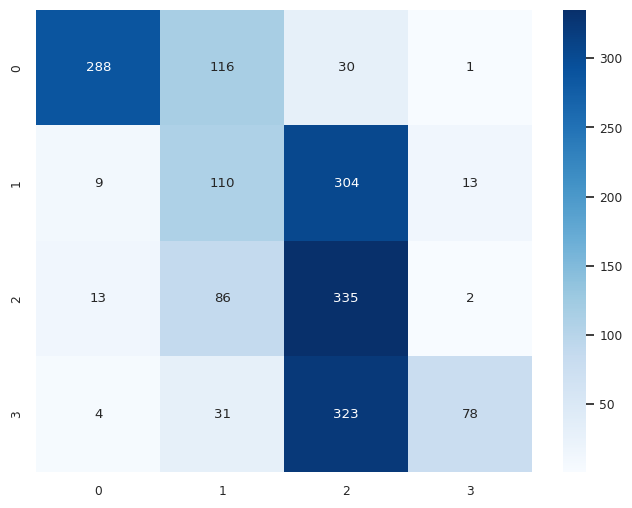

In [5]:
evaluate_finetuned_model()